# Exploratory Data Analysis, Hypothesis Testing, and Feature Engineering Reflection

**Dataset:** Netflix titles dataset  
**Due date:** May 20  

This notebook continues the previous preprocessing work. The dataset contains Netflix Movies and TV Shows with attributes such as title, cast, country, release year, rating, duration and description. The cleaned file is used as the main analytical base because missing values were already treated where appropriate, `date_added` was converted to a date field, and `duration` was separated into `duration_minutes` for movies and `seasons` for TV shows.

The goal is to explore the dataset, describe patterns, analyze variation and relationships, perform a coherent hypothesis test, and reflect on feature engineering and dimensionality reduction decisions.

## 1. Setup and data loading

The analysis uses the cleaned dataset as the primary source. The original file is only kept as a reference for the preprocessing decisions already made in previous activities.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from collections import Counter

plt.rcParams["figure.figsize"] = (9, 5)

DATA_PATH = "netflix_cleaned.csv"

df = pd.read_csv(DATA_PATH)
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (8807, 14)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_minutes,seasons
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0,NaN
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",NaN,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,NaN,1.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",NaN,1.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,NaN,2.0


## 2. Data dictionary and analytical variables

The dataset contains categorical variables such as `type`, `rating`, `country`, `listed_in`, `director` and `cast`, plus numerical or date-related variables such as `release_year`, `duration_minutes`, `seasons` and `date_added`.

For analysis, `duration_minutes` is interpreted only for movies, while `seasons` is interpreted only for TV shows. This avoids comparing incompatible units.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   show_id           8807 non-null   object        
 1   type              8807 non-null   object        
 2   title             8807 non-null   object        
 3   director          8807 non-null   object        
 4   cast              8807 non-null   object        
 5   country           8807 non-null   object        
 6   date_added        8709 non-null   datetime64[ns]
 7   release_year      8807 non-null   int64         
 8   rating            8803 non-null   object        
 9   duration          8804 non-null   object        
 10  listed_in         8807 non-null   object        
 11  description       8807 non-null   object        
 12  duration_minutes  6128 non-null   float64       
 13  seasons           2676 non-null   float64       
dtypes: datetime64[ns](1), fl

## 3. Data quality check

The cleaned dataset should be consistent enough for exploratory analysis, but it is still important to verify missing values, duplicated records and variable types before producing conclusions.

In [3]:
quality_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique()
}).sort_values("missing_percent", ascending=False)

print("Duplicated rows:", df.duplicated().sum())
quality_summary

Duplicated rows: 0


,missing_count,missing_percent,unique_values
seasons,6131,69.62,15
duration_minutes,2679,30.42,205
date_added,98,1.11,1699
rating,4,0.05,17
duration,3,0.03,220
show_id,0,0.00,8807
country,0,0.00,749
cast,0,0.00,7693
director,0,0.00,4529
title,0,0.00,8807


**Interpretation.** The columns `duration_minutes` and `seasons` have many missing values because they apply to different content types: movies have minutes, TV shows have seasons. Therefore, these missing values are structural, not necessarily data quality errors. The remaining missing values are low after preprocessing, especially compared with the original dataset.

## 4. Descriptive statistics

This section calculates measures of central tendency and dispersion for the main numerical variables.

In [4]:
numeric_summary = df[["release_year", "duration_minutes", "seasons"]].describe().T
numeric_summary["median"] = df[["release_year", "duration_minutes", "seasons"]].median(numeric_only=True)
numeric_summary = numeric_summary[["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max"]]
numeric_summary.round(2)

,count,mean,median,std,min,25%,50%,75%,max
release_year,8807.0,2014.18,2017.0,8.82,1925.0,2013.0,2017.0,2019.0,2021.0
duration_minutes,6128.0,99.58,98.0,28.29,3.0,87.0,98.0,114.0,312.0
seasons,2676.0,1.76,1.0,1.58,1.0,1.0,1.0,2.0,17.0


**Interpretation.** Most titles are recent, with the median release year around 2017. Movie duration is centered close to 98 minutes, while TV Shows are mostly short in number of seasons, with median equal to 1 season. This suggests that the catalog is concentrated in recent releases and in TV productions with few seasons.

## 5. Content type distribution

The first exploratory question is whether the catalog is balanced between Movies and TV Shows.

In [5]:
type_counts = df["type"].value_counts()
type_percent = (df["type"].value_counts(normalize=True) * 100).round(2)
pd.DataFrame({"count": type_counts, "percent": type_percent})

,count,percent
type,,
Movie,6131,69.62
TV Show,2676,30.38


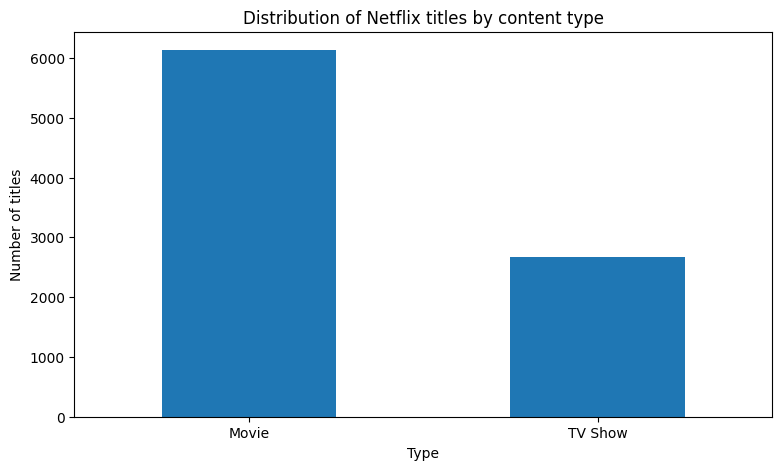

In [6]:
ax = type_counts.plot(kind="bar")
ax.set_title("Distribution of Netflix titles by content type")
ax.set_xlabel("Type")
ax.set_ylabel("Number of titles")
plt.xticks(rotation=0)
plt.show()

**Interpretation.** Movies represent the largest part of the dataset. This is important because general conclusions about the dataset may be influenced more strongly by movie patterns than by TV Show patterns.

## 6. Distribution and dispersion analysis

This section analyzes variation, distribution shape and possible outliers in release year, movie duration and TV Show seasons.

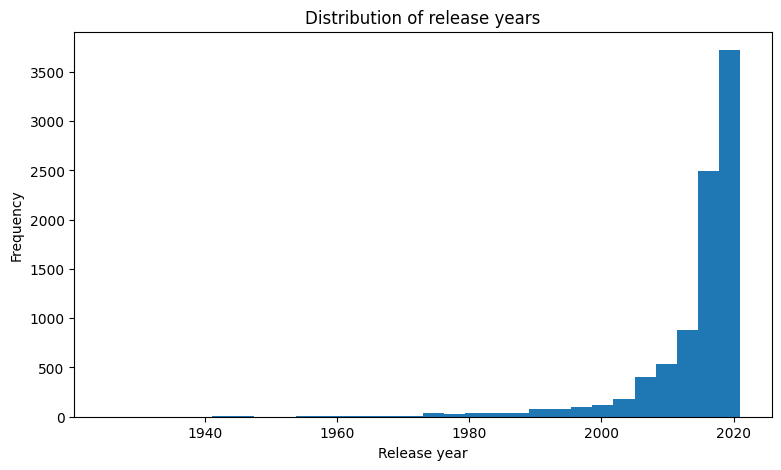

In [7]:
ax = df["release_year"].plot(kind="hist", bins=30)
ax.set_title("Distribution of release years")
ax.set_xlabel("Release year")
ax.set_ylabel("Frequency")
plt.show()

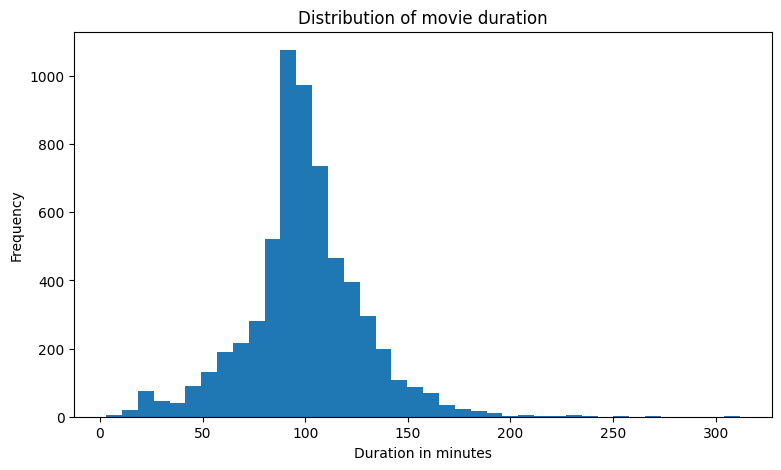

In [8]:
movies = df[df["type"] == "Movie"].dropna(subset=["duration_minutes"]).copy()
tvshows = df[df["type"] == "TV Show"].dropna(subset=["seasons"]).copy()

ax = movies["duration_minutes"].plot(kind="hist", bins=40)
ax.set_title("Distribution of movie duration")
ax.set_xlabel("Duration in minutes")
ax.set_ylabel("Frequency")
plt.show()

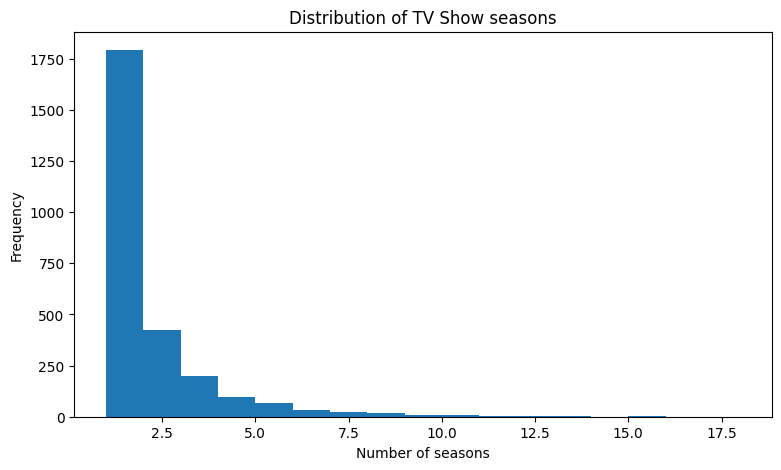

In [9]:
ax = tvshows["seasons"].plot(kind="hist", bins=range(1, int(tvshows["seasons"].max()) + 2))
ax.set_title("Distribution of TV Show seasons")
ax.set_xlabel("Number of seasons")
ax.set_ylabel("Frequency")
plt.show()

/tmp/ipykernel_2591/3308100837.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([movies["duration_minutes"], tvshows["seasons"]], labels=["Movie duration (min)", "TV seasons"])


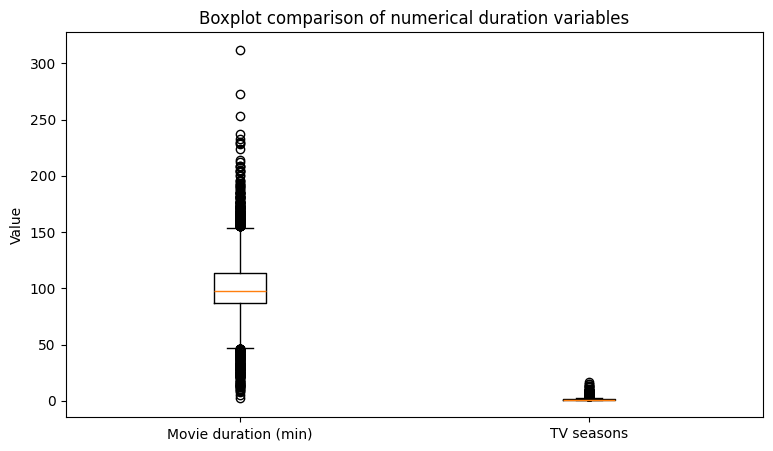

In [10]:
fig, ax = plt.subplots()
ax.boxplot([movies["duration_minutes"], tvshows["seasons"]], labels=["Movie duration (min)", "TV seasons"])
ax.set_title("Boxplot comparison of numerical duration variables")
ax.set_ylabel("Value")
plt.show()

In [11]:
def iqr_outlier_summary(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    return pd.Series({
        "q1": q1, "q3": q3, "iqr": iqr,
        "lower_bound": lower, "upper_bound": upper,
        "outlier_count": outliers.count(),
        "outlier_percent": round(outliers.count() / series.count() * 100, 2)
    })

outlier_summary = pd.DataFrame({
    "movie_duration_minutes": iqr_outlier_summary(movies["duration_minutes"]),
    "tv_show_seasons": iqr_outlier_summary(tvshows["seasons"])
})
outlier_summary

,movie_duration_minutes,tv_show_seasons
q1,87.00,1.00
q3,114.00,2.00
iqr,27.00,1.00
lower_bound,46.50,-0.50
upper_bound,154.50,3.50
outlier_count,450.00,259.00
outlier_percent,7.34,9.68


**Interpretation.** Movie duration has a concentration around standard feature-length values, but there are outliers with very short or very long durations. TV Shows are highly concentrated at 1 season, and titles with many seasons appear as upper outliers. These outliers should not be removed automatically because they may represent valid catalog items.

## 7. Genre/category exploration

The `listed_in` column contains multiple categories separated by commas. For analysis, categories are split and counted individually.

In [12]:
category_counter = Counter()
for value in df["listed_in"].dropna():
    for category in str(value).split(","):
        category_counter[category.strip()] += 1

top_categories = pd.DataFrame(category_counter.most_common(15), columns=["category", "count"])
top_categories

,category,count
0,International Movies,2752
1,Dramas,2427
2,Comedies,1674
3,International TV Shows,1351
4,Documentaries,869
5,Action & Adventure,859
6,TV Dramas,763
7,Independent Movies,756
8,Children & Family Movies,641
9,Romantic Movies,616


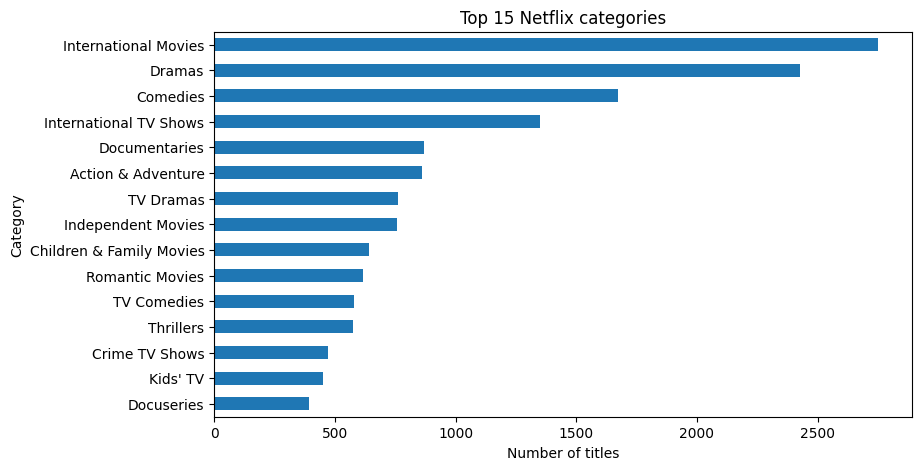

In [13]:
ax = top_categories.sort_values("count").plot(kind="barh", x="category", y="count", legend=False)
ax.set_title("Top 15 Netflix categories")
ax.set_xlabel("Number of titles")
ax.set_ylabel("Category")
plt.show()

**Interpretation.** International Movies, Dramas and Comedies are among the most frequent categories. Because each title may have more than one category, these counts should be interpreted as category occurrences rather than mutually exclusive classes.

## 8. Correlation analysis

Correlation is calculated only for numerical variables. Methodological caution is necessary because `duration_minutes` applies to movies and `seasons` applies to TV Shows, so the two should not be interpreted as directly comparable.

In [14]:
corr = df[["release_year", "duration_minutes", "seasons"]].corr(numeric_only=True)
corr.round(3)

,release_year,duration_minutes,seasons
release_year,1.000,-0.206,-0.09
duration_minutes,-0.206,1.000,NaN
seasons,-0.090,NaN,1.00


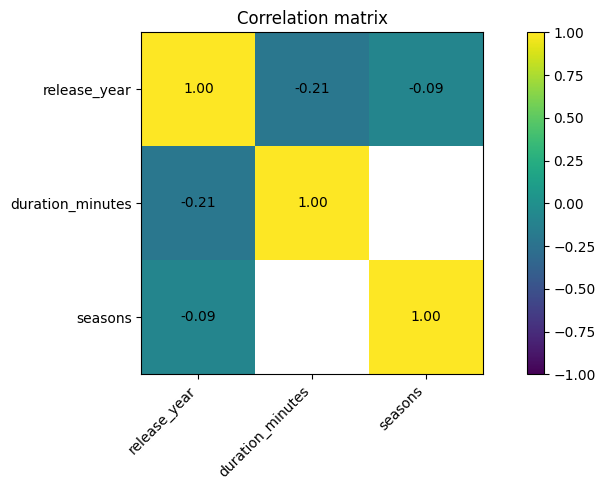

In [15]:
fig, ax = plt.subplots()
im = ax.imshow(corr, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        value = corr.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f"{value:.2f}", ha="center", va="center")
ax.set_title("Correlation matrix")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

**Interpretation.** There is a weak negative relationship between release year and movie duration, indicating that newer movies in the dataset tend to be slightly shorter. This is not strong enough to imply causality. Correlation also does not account for genre, country, rating or platform acquisition strategy, which may explain part of the variation.

## 9. Hypothesis testing

### Research question
Are Netflix movies associated with the United States different in duration from movies not associated with the United States?

### Variables
- Group variable: whether the `country` field contains “United States”.
- Numeric variable: `duration_minutes`, only for Movies.

### Hypotheses
- **H0:** There is no difference in movie duration between U.S. and non-U.S. movies.
- **H1:** There is a difference in movie duration between U.S. and non-U.S. movies.

Because the two groups are independent and the sample is large, a Welch two-sample t-test is appropriate for comparing means when variances are not assumed equal. A Mann-Whitney U test is also reported as a non-parametric robustness check.

In [16]:
movies["is_us_movie"] = movies["country"].str.contains("United States", na=False)

us_movies = movies.loc[movies["is_us_movie"], "duration_minutes"]
non_us_movies = movies.loc[~movies["is_us_movie"], "duration_minutes"]

group_summary = pd.DataFrame({
    "group": ["U.S. movies", "Non-U.S. movies"],
    "count": [us_movies.count(), non_us_movies.count()],
    "mean": [us_movies.mean(), non_us_movies.mean()],
    "median": [us_movies.median(), non_us_movies.median()],
    "std": [us_movies.std(), non_us_movies.std()]
})
group_summary.round(2)

,group,count,mean,median,std
0,U.S. movies,2749,93.75,94.0,25.20
1,Non-U.S. movies,3379,104.31,103.0,29.75


In [17]:
levene_result = stats.levene(us_movies, non_us_movies)
welch_result = stats.ttest_ind(us_movies, non_us_movies, equal_var=False)
mannwhitney_result = stats.mannwhitneyu(us_movies, non_us_movies, alternative="two-sided")

results = pd.DataFrame({
    "test": ["Levene variance test", "Welch t-test", "Mann-Whitney U test"],
    "statistic": [levene_result.statistic, welch_result.statistic, mannwhitney_result.statistic],
    "p_value": [levene_result.pvalue, welch_result.pvalue, mannwhitney_result.pvalue]
})
results

,test,statistic,p_value
0,Levene variance test,7.344523e+01,1.294860e-17
1,Welch t-test,-1.504241e+01,3.040408e-50
2,Mann-Whitney U test,3.537682e+06,4.150895e-58


/tmp/ipykernel_2591/4068012513.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([us_movies, non_us_movies], labels=["U.S. movies", "Non-U.S. movies"])


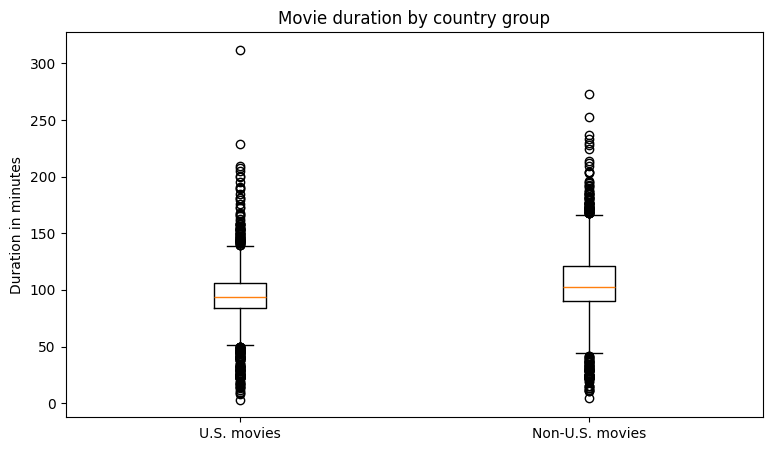

In [18]:
fig, ax = plt.subplots()
ax.boxplot([us_movies, non_us_movies], labels=["U.S. movies", "Non-U.S. movies"])
ax.set_title("Movie duration by country group")
ax.set_ylabel("Duration in minutes")
plt.show()

**Interpretation.** The p-value from the Welch t-test is far below 0.05, so the null hypothesis is rejected. In this dataset, U.S. movies and non-U.S. movies have statistically different average durations. The descriptive statistics show that non-U.S. movies have a higher mean and median duration than U.S. movies.

This result should be interpreted carefully. The `country` field can contain multiple countries, and “non-U.S.” is a broad group that mixes different production markets and genres. Therefore, the test identifies an association in this dataset, not a causal explanation.

## 10. Feature engineering and dimensionality reduction reflection

The dataset can support recommendation, classification, catalog analysis and text mining tasks. The necessary transformations depend on the modeling objective. For exploratory analysis, only a few derived variables are necessary. For machine learning, more transformations would be useful.

In [19]:
engineered = df.copy()
engineered["year_added"] = engineered["date_added"].dt.year
engineered["month_added"] = engineered["date_added"].dt.month
engineered["is_movie"] = (engineered["type"] == "Movie").astype(int)
engineered["is_tv_show"] = (engineered["type"] == "TV Show").astype(int)
engineered["content_age"] = engineered["year_added"] - engineered["release_year"]
engineered["main_country"] = engineered["country"].fillna("Unknown").str.split(",").str[0].str.strip()
engineered["main_category"] = engineered["listed_in"].fillna("Unknown").str.split(",").str[0].str.strip()
engineered[["title", "type", "release_year", "year_added", "content_age", "main_country", "main_category"]].head()

,title,type,release_year,year_added,content_age,main_country,main_category
0,Dick Johnson Is Dead,Movie,2020,2021.0,1.0,United States,Documentaries
1,Blood & Water,TV Show,2021,2021.0,0.0,South Africa,International TV Shows
2,Ganglands,TV Show,2021,2021.0,0.0,Unknown,Crime TV Shows
3,Jailbirds New Orleans,TV Show,2021,2021.0,0.0,Unknown,Docuseries
4,Kota Factory,TV Show,2021,2021.0,0.0,India,International TV Shows


### Completed feature engineering checklist

| Checklist item | Decision | Justification for this dataset |
|---|---|---|
| Missing value handling | Required and already mostly performed | `director`, `cast` and `country` can use “Unknown” when absence is not critical. `duration_minutes` and `seasons` should remain separate because missingness is structural by content type. |
| Date transformation | Required | `date_added` should be converted to datetime and can generate `year_added`, `month_added` and content age. |
| Duration transformation | Required | Movies and TV Shows use different units, so `duration` should be separated into movie minutes and TV seasons. |
| Categorical encoding | Required for modeling | `type`, `rating`, `main_country` and `main_category` can be encoded using one-hot encoding or target encoding depending on the model. |
| Multi-label category processing | Recommended | `listed_in` contains multiple categories. Splitting it creates better genre indicators. |
| Text feature extraction | Optional but valuable | `description` can be transformed with TF-IDF or embeddings for recommendation or content similarity. |
| Scaling | Required only for distance-based models | Variables like duration and content age should be standardized for KNN, clustering or PCA, but not necessarily for tree-based models. |
| Outlier treatment | Review, do not automatically remove | Very long movies or shows with many seasons may be valid titles. Outliers should be capped or removed only if the modeling objective requires it. |
| Dimensionality reduction | Optional | PCA is not necessary for the basic EDA. It may help if many encoded genre/country/text variables create a high-dimensional matrix. |
| Data leakage check | Required for predictive modeling | If predicting popularity or content availability, variables created after the target event should be avoided. |
| Final recommendation | Additional feature engineering is useful before modeling | The dataset is suitable for EDA now, but modeling would benefit from date, category, country and text-derived features. |

## 11. Final conclusions

The Netflix dataset is suitable for exploratory analysis after preprocessing. The catalog contains more Movies than TV Shows and is concentrated in recent years. Movie durations are centered around typical feature length, while TV Shows are mostly concentrated at one season. The category analysis shows a strong presence of international content, dramas and comedies.

The hypothesis test found a statistically significant difference between the duration of U.S. and non-U.S. movies, with non-U.S. movies showing higher average and median duration in this dataset. This should be interpreted as an observed association, not as a causal claim.

For future modeling, the most relevant feature engineering steps would be: extracting date features, creating content age, separating main country and main category, one-hot encoding categorical variables, processing multi-label genres, and applying text vectorization to descriptions. Dimensionality reduction is not required for the current EDA, but it may be useful if the project evolves into recommendation systems, clustering or high-dimensional text analysis.